# LSTM Weather Forecasting — Statistics & Comparison

This notebook loads **all trained models from Google Drive** (including the true 10-epoch baseline),
evaluates them on the validation set, and produces:

1. **Bar chart** — Val MSE / MAE / RMSE comparison across all experiments
2. **Prediction plots** — True baseline (10-epoch) vs best experiment model

No re-training is performed. Everything is loaded from saved `.keras` files.

## 1. Setup & Imports

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
import os
from zipfile import ZipFile
from google.colab import drive
from keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

drive.mount('/content/drive')
DRIVE_SAVE_DIR = '/content/drive/MyDrive/CMPE401/LSTM'

print('Keras version:', keras.__version__)
print('Drive dir    :', DRIVE_SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Keras version: 3.13.2
Drive dir    : /content/drive/MyDrive/CMPE401/LSTM


## 2. Load & Preprocess Data

Identical preprocessing to `experiments.ipynb` — must match exactly so the validation
dataset is the same one the models were evaluated on during training.

In [21]:
# ── Download / locate dataset ─────────────────────────────────────────────────
uri      = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
ZipFile(zip_path).extractall()
df = pd.read_csv("jena_climate_2009_2016.csv")
print(f"Dataset shape: {df.shape}")

Dataset shape: (420551, 15)


In [22]:
# ── Shared hyperparameters (must match experiments.ipynb exactly) ─────────────
split_fraction = 0.715
train_split    = int(split_fraction * int(df.shape[0]))
step           = 6
past           = 720
future         = 72
BATCH_SIZE     = 2048

feature_keys = [
    "p (mbar)", "T (degC)", "Tpot (K)", "Tdew (degC)",
    "rh (%)", "VPmax (mbar)", "VPact (mbar)",
    "VPdef (mbar)", "sh (g/kg)", "H2OC (mmol/mol)",
    "rho (g/m**3)", "wv (m/s)", "max. wv (m/s)", "wd (deg)",
]
selected_features = [feature_keys[i] for i in [0, 1, 5, 7, 8, 10, 11]]

def normalize(data, train_split):
    data_mean = data[:train_split].mean(axis=0)
    data_std  = data[:train_split].std(axis=0)
    return (data - data_mean) / data_std

features = df[selected_features]
features.index = df["Date Time"]
features = normalize(features.values, train_split)
features = pd.DataFrame(features)

train_data = features.loc[0 : train_split - 1]
val_data   = features.loc[train_split:]

sequence_length = int(past / step)   # 120 timesteps per window

# ── Validation dataset only (no training needed) ──────────────────────────────
x_end       = len(val_data) - past - future
label_start = train_split + past + future
x_val       = val_data.iloc[:x_end][[i for i in range(7)]].values
y_val       = features.iloc[label_start:][[1]]

dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    x_val, y_val,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=BATCH_SIZE,
).cache().prefetch(tf.data.AUTOTUNE)

print("Validation dataset ready.")
for batch in dataset_val.take(1):
    x_sample, y_sample = batch
    print("  x shape:", x_sample.numpy().shape)
    print("  y shape:", y_sample.numpy().shape)

Validation dataset ready.
  x shape: (2048, 120, 7)
  y shape: (2048, 1)


## 3. Model Registry

Define every model from `experiments.ipynb` plus the **true 10-epoch baseline**.
Each entry maps a display name → `.keras` file path on Drive.

In [23]:
# ── Model file registry ───────────────────────────────────────────────────────
# Keys are display names; values are paths relative to DRIVE_SAVE_DIR.
# The true baseline (10-epoch) uses a different filename from the 50-epoch one.
MODEL_FILES = {
    "Baseline LSTM-32 (10 ep)"  : "lstm_baseline.keras",          # 10-epoch original
    "LSTM-32 (50 ep)"       : "Baseline_LSTM-32.keras",       # 50-epoch exp-0
    "Stacked LSTM 64-32"     : "Stacked_LSTM_64-32.keras",
    "Large LSTM-128"         : "Large_LSTM-128.keras",
    "Bidirectional LSTM-32"  : "Bidirectional_LSTM-32.keras",
    "CNN + LSTM Hybrid"      : "CNN_+_LSTM_Hybrid.keras",
}

# Verify all files exist before proceeding
print("Checking Drive files...")
missing = []
for name, fname in MODEL_FILES.items():
    path = os.path.join(DRIVE_SAVE_DIR, fname)
    exists = os.path.isfile(path)
    status = "✓" if exists else "✗  MISSING"
    print(f"  {status}  {name:<28s}  →  {fname}")
    if not exists:
        missing.append(name)

if missing:
    print(f"\nWarning  {len(missing)} file(s) not found — check filenames above.")
else:
    print("\nAll model files found.")

Checking Drive files...
  ✓  Baseline LSTM-32 (10 ep)      →  lstm_baseline.keras
  ✓  LSTM-32 (50 ep)               →  Baseline_LSTM-32.keras
  ✓  Stacked LSTM 64-32            →  Stacked_LSTM_64-32.keras
  ✓  Large LSTM-128                →  Large_LSTM-128.keras
  ✓  Bidirectional LSTM-32         →  Bidirectional_LSTM-32.keras
  ✓  CNN + LSTM Hybrid             →  CNN_+_LSTM_Hybrid.keras

All model files found.


## 4. Load Models & Evaluate on Validation Set

In [24]:
def evaluate_model(model, dataset):
    """Return MSE, MAE, RMSE on a tf.data.Dataset."""
    y_true_list, y_pred_list = [], []
    for x_batch, y_batch in dataset:
        preds = model.predict(x_batch, verbose=0)
        y_true_list.append(y_batch.numpy())
        y_pred_list.append(preds)
    y_true = np.concatenate(y_true_list)
    y_pred = np.concatenate(y_pred_list)
    mse  = float(np.mean((y_true - y_pred) ** 2))
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(mse))
    return {"MSE": mse, "MAE": mae, "RMSE": rmse}


# ── Load every model and evaluate ────────────────────────────────────────────
LOADED = {}   # name → {"model": ..., "metrics": ...}

for name, fname in MODEL_FILES.items():
    path = os.path.join(DRIVE_SAVE_DIR, fname)
    if not os.path.isfile(path):
        print(f"  ⚠️  Skipping '{name}' — file not found.")
        continue
    print(f"Loading  {name}  ...", end="  ")
    model = keras.models.load_model(path)
    metrics = evaluate_model(model, dataset_val)
    LOADED[name] = {"model": model, "metrics": metrics}
    print(f"MSE={metrics['MSE']:.4f}  MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}")

print(f"\nLoaded {len(LOADED)} / {len(MODEL_FILES)} models.")

Loading  Baseline LSTM-32 (10 ep)  ...  

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 16 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 12 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


MSE=0.1291  MAE=0.2833  RMSE=0.3593
Loading  LSTM-32 (50 ep)  ...  MSE=0.0986  MAE=0.2453  RMSE=0.3140
Loading  Stacked LSTM 64-32  ...  MSE=0.0977  MAE=0.2445  RMSE=0.3125
Loading  Large LSTM-128  ...  MSE=0.1063  MAE=0.2553  RMSE=0.3260
Loading  Bidirectional LSTM-32  ...  MSE=0.0988  MAE=0.2475  RMSE=0.3143
Loading  CNN + LSTM Hybrid  ...  MSE=0.1182  MAE=0.2709  RMSE=0.3439

Loaded 6 / 6 models.


## 5. Build Summary DataFrame

In [25]:
rows = []
for name, result in LOADED.items():
    m = result["metrics"]
    rows.append({
        "Experiment" : name,
        "Val MSE"    : round(m["MSE"],  4),
        "Val MAE"    : round(m["MAE"],  4),
        "Val RMSE"   : round(m["RMSE"], 4),
        "Params"     : LOADED[name]["model"].count_params(),
    })

summary_df = pd.DataFrame(rows).set_index("Experiment")
summary_df = summary_df.sort_values("Val MSE")

best_exp      = summary_df["Val MSE"].idxmin()
true_baseline = "Baseline LSTM-32 (10 ep)"

print("=== VALIDATION METRICS ===")
print(summary_df.to_string())
print(f"\n  Best model : {best_exp}")
print(f"  True baseline MSE : {summary_df.loc[true_baseline, 'Val MSE'] if true_baseline in summary_df.index else 'n/a'}")

=== VALIDATION METRICS ===
                          Val MSE  Val MAE  Val RMSE  Params
Experiment                                                  
Stacked LSTM 64-32         0.0977   0.2445    0.3125   30881
LSTM-32 (50 ep)            0.0986   0.2453    0.3140    5153
Bidirectional LSTM-32      0.0988   0.2475    0.3143   10305
Large LSTM-128             0.1063   0.2553    0.3260   69761
CNN + LSTM Hybrid          0.1182   0.2709    0.3439   13857
Baseline LSTM-32 (10 ep)   0.1291   0.2833    0.3593    5153

  Best model : Stacked LSTM 64-32
  True baseline MSE : 0.1291


## 6. Bar Chart — Validation Metric Comparison

Three side-by-side bar charts (Val MSE, Val MAE, Val RMSE).
The **True Baseline** bar is highlighted in a distinct colour.

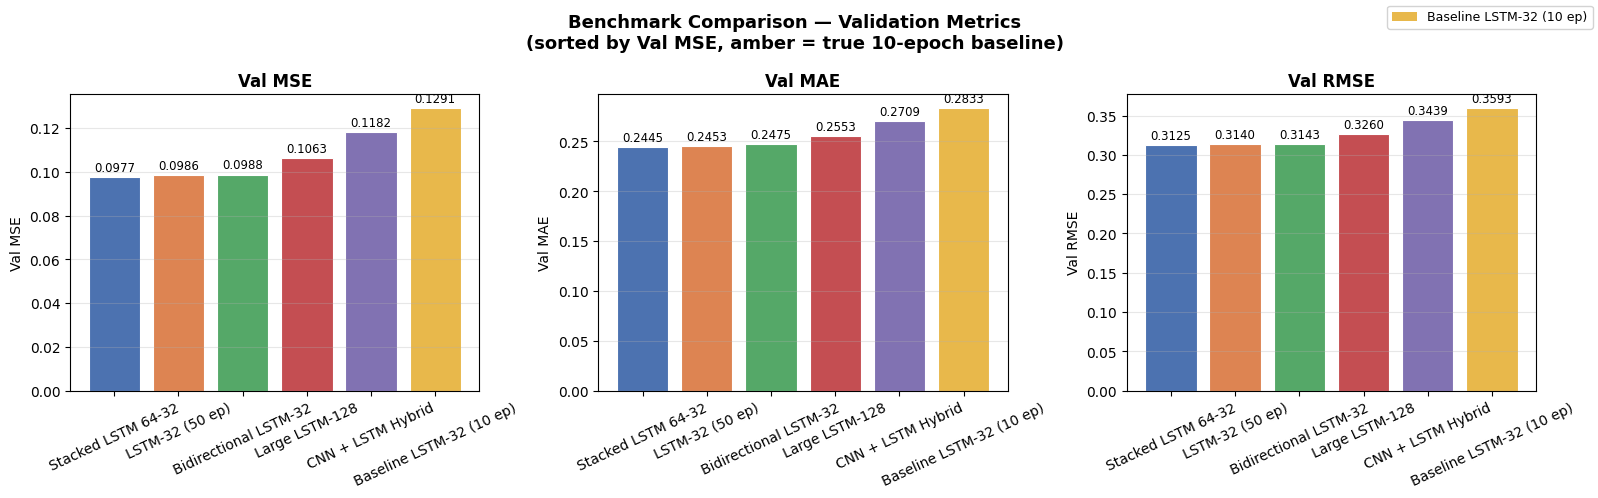

Saved: benchmark_metrics.png


In [26]:
metrics_to_plot = ["Val MSE", "Val MAE", "Val RMSE"]

# Colour palette: true baseline gets its own colour, rest cycle through the palette
PALETTE      = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
BASELINE_CLR = "#E8B84B"   # amber — visually distinct

names  = summary_df.index.tolist()   # already sorted by Val MSE
colors = []
palette_idx = 0
for n in names:
    if n == true_baseline:
        colors.append(BASELINE_CLR)
    else:
        colors.append(PALETTE[palette_idx % len(PALETTE)])
        palette_idx += 1

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metrics_to_plot):
    vals = summary_df[metric].values
    bars = ax.bar(names, vals, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.01,
            f"{val:.4f}",
            ha="center", va="bottom", fontsize=8.5
        )

# Legend patch for the true baseline colour
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=BASELINE_CLR, label=f'{true_baseline}'),
]
fig.legend(handles=legend_elements, loc="upper right", fontsize=9, framealpha=0.85)

plt.suptitle(
    "Benchmark Comparison — Validation Metrics\n(sorted by Val MSE, amber = true 10-epoch baseline)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("benchmark_metrics.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: benchmark_metrics.png")

## 7. Prediction Plots — True Baseline vs Best Model

Each column shows one validation window: blue line = temperature history,
red ✕ = true future temperature, green ● = model prediction.

In [27]:
def show_predictions(model, name, n_samples=5):
    """Plot history + true future + model prediction for n_samples windows."""
    fig, axes = plt.subplots(1, n_samples, figsize=(18, 3.5), sharey=True)
    for ax, (x_batch, y_batch) in zip(axes, dataset_val.unbatch().batch(1).take(n_samples)):
        history_vals = x_batch[0, :, 1].numpy()   # temperature channel (index 1)
        true_future  = y_batch[0].numpy()
        pred_future  = model.predict(x_batch, verbose=0)[0]

        time_steps = list(range(-len(history_vals), 0))
        ax.plot(time_steps, history_vals, "b.-", markersize=3, label="History")
        ax.plot(12, true_future, "rx", markersize=10, label="True")
        ax.plot(12, pred_future, "go", markersize=10, label="Predicted")
        ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
        ax.set_xlabel("Time Step")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Normalised Temperature")
    axes[0].legend(fontsize=8)
    plt.suptitle(f"Predictions — {name}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    safe = name.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f"predictions_{safe}.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"Saved: predictions_{safe}.png")

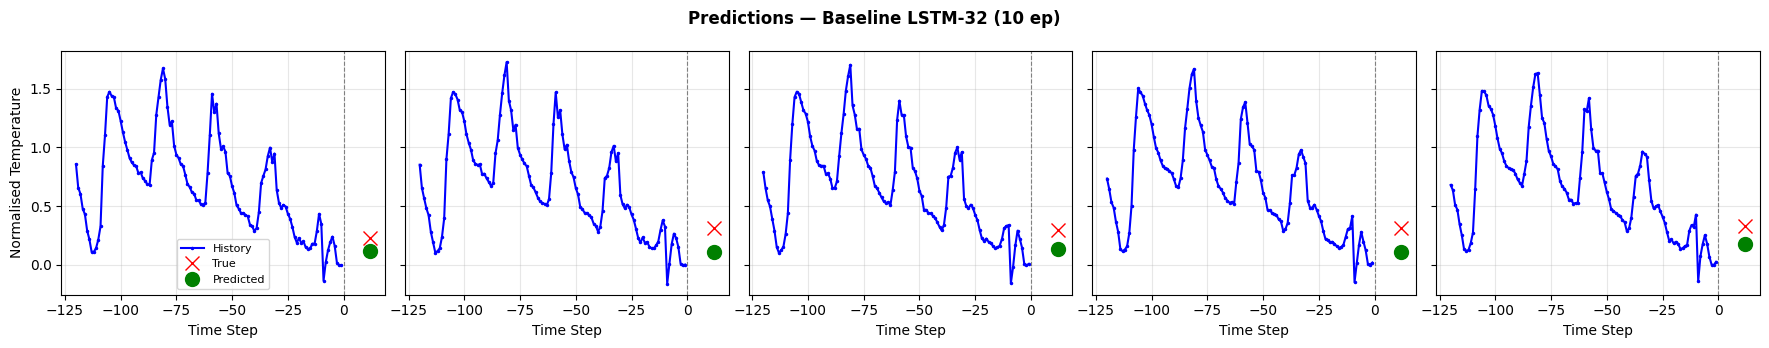

Saved: predictions_Baseline_LSTM-32_10_ep.png


In [28]:
# ── True 10-epoch baseline ────────────────────────────────────────────────────
if true_baseline in LOADED:
    show_predictions(LOADED[true_baseline]["model"], true_baseline)
else:
    print(f"⚠️  '{true_baseline}' was not loaded — skipping its prediction plot.")

Best model: Stacked LSTM 64-32  (Val MSE = 0.0977)


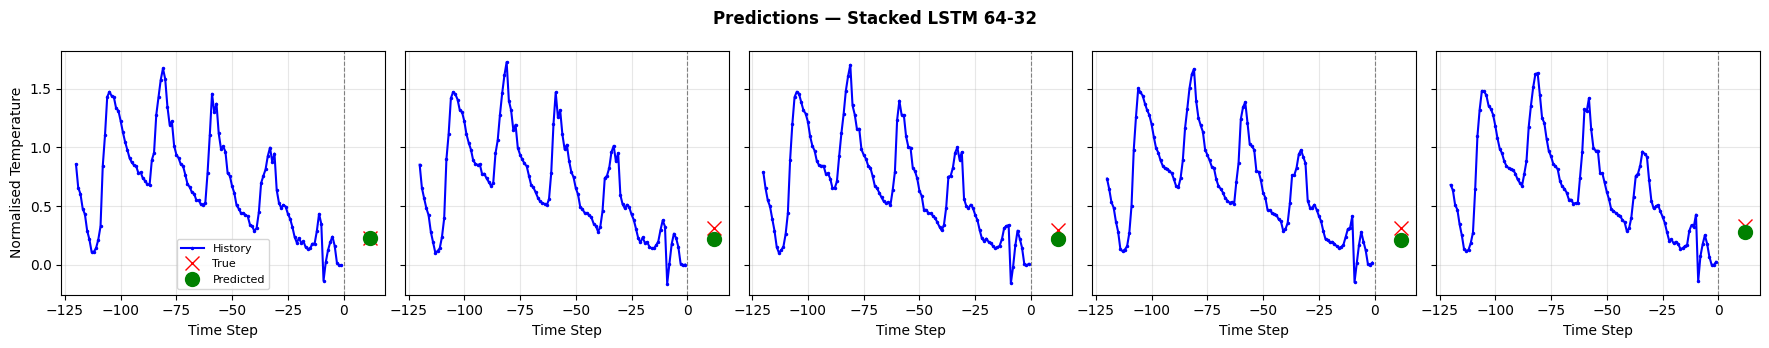

Saved: predictions_Stacked_LSTM_64-32.png


In [29]:
# ── Best experiment model ─────────────────────────────────────────────────────
# 'best_exp' is determined by lowest Val MSE across all loaded models.
# If the true baseline happens to be the best, we still show it for comparison.
print(f"Best model: {best_exp}  (Val MSE = {summary_df.loc[best_exp, 'Val MSE']:.4f})")

if best_exp in LOADED:
    show_predictions(LOADED[best_exp]["model"], best_exp)
else:
    print(f"⚠️  Best model '{best_exp}' was not loaded — skipping.")

## 8. Summary

Quick printout comparing the true baseline against the best experiment model.

In [30]:
print("=" * 55)
print("  FINAL COMPARISON")
print("=" * 55)
print(f"  {'Model':<30s}  {'Val MSE':>8s}  {'Val MAE':>8s}  {'Val RMSE':>9s}")
print("-" * 55)

highlight = {true_baseline, best_exp}
for name in summary_df.index:
    row = summary_df.loc[name]
    tag = "  <- best" if name == best_exp and name != true_baseline else ""
    tag = "  <- true baseline" if name == true_baseline else tag
    print(f"  {name:<30s}  {row['Val MSE']:>8.4f}  {row['Val MAE']:>8.4f}  {row['Val RMSE']:>9.4f}{tag}")

print("=" * 55)

if true_baseline in summary_df.index and best_exp != true_baseline:
    tb_mse   = summary_df.loc[true_baseline, "Val MSE"]
    best_mse = summary_df.loc[best_exp,      "Val MSE"]
    delta    = best_mse - tb_mse
    pct      = delta / tb_mse * 100
    sign     = "+" if delta > 0 else ""
    print(f"\n  Best vs True Baseline: ΔMSE = {sign}{delta:.4f}  ({sign}{pct:.1f}%)")

  FINAL COMPARISON
  Model                            Val MSE   Val MAE   Val RMSE
-------------------------------------------------------
  Stacked LSTM 64-32                0.0977    0.2445     0.3125  <- best
  LSTM-32 (50 ep)                   0.0986    0.2453     0.3140
  Bidirectional LSTM-32             0.0988    0.2475     0.3143
  Large LSTM-128                    0.1063    0.2553     0.3260
  CNN + LSTM Hybrid                 0.1182    0.2709     0.3439
  Baseline LSTM-32 (10 ep)          0.1291    0.2833     0.3593  <- true baseline

  Best vs True Baseline: ΔMSE = -0.0314  (-24.3%)
